# Analyse Spatiale du Discours Électoral (1973-1993)
## Annotations GLiNER checkpoint-800

Trois niveaux géographiques classifiés via NER (GLiNER fine-tuné) + gazetteer :

| Niveau | Définition | Méthode |
|--------|-----------|---------|
| **Local** | Département du candidat | NER LOC + correspondance département |
| **National** | Autre lieu français | NER LOC + gazetteer France |
| **Supranational** | Hors France (villes étrangères, org. intl.) | NER LOC + gazetteer Intl + Regex |

> **Source NER** : `archelec_gliner800_loc.json` — 10 598 docs annotés avec GLiNER checkpoint-800 sur Tesla T4


## 1 — Imports & Configuration

In [3]:
import os, re, json, unicodedata
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

# ROOT = dossier projet (un niveau au-dessus de notebooks/)
ROOT_DIR   = Path("..").resolve()
DATA_DIR   = ROOT_DIR / "data"
GRAPHS_DIR = ROOT_DIR / "data/results/output_best_model/graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
assert (DATA_DIR / "annotated/archelec_gliner800_loc.json").exists(), "Fichier GLiNER manquant!"

plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":11,"axes.titlesize":13,
    "axes.titleweight":"bold","axes.spines.top":False,"axes.spines.right":False,
    "legend.frameon":False,"figure.dpi":100,"savefig.dpi":300,"savefig.bbox":"tight",
})
C_BLOC  = {"gauche":"#c0392b","centre":"#f39c12","droite":"#2980b9","non classé":"#95a5a6"}
C_SCALE = {"local":"#27ae60","national":"#e67e22","supranational":"#8e44ad"}
ANNEE_ORDER = [1973, 1978, 1981, 1988, 1993]
PRES_LABELS = {1973:"Pompidou",1978:"Giscard",1981:"Mitterrand I",
               1988:"Mitterrand II",1993:"Cohabitation"}
BG_BANDS  = [([0,0],"Pompidou"),([1,1],"Giscard"),([2,4],"Mitterrand")]
BG_COLORS = ["#e8daef","#d5f5e3","#fdebd0"]


ROOT_DIR: /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec


## 2 — Chargement des données

In [4]:
# Annotations GLiNER checkpoint-800 (LOC + PER détectés)
with open(DATA_DIR / "annotated/archelec_gliner800_loc.json") as f:
    docs_gliner = json.load(f)

# Métadonnées (partis, départements, etc.)
df_meta = pd.read_csv(DATA_DIR / "processed/archelec_1958_2019.csv",
                      encoding="latin-1", low_memory=False)
df_meta.columns = df_meta.columns.str.strip()
df_meta = df_meta[df_meta["annee"].between(1973, 1993)].copy()

# Corpus sentiment (pour croisement spatial × opinion)
df_sentiment = pd.read_excel(
    DATA_DIR / "results/output_best_model/leaders_sentiment_corpus.xlsx"
)

from collections import Counter
yr_dist = Counter(d["annee"] for d in docs_gliner)
print(f"Docs GLiNER     : {len(docs_gliner):,}")
print(f"Années          : {dict(sorted(yr_dist.items()))}")
print(f"Métadonnées     : {len(df_meta):,}")
print(f"Sentiment corpus: {len(df_sentiment):,}")


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## 3 — Gazetteers & Classification géographique

In [ ]:
FRANCE_SET = {
    # Départements
    "ain","aisne","allier","alpes-de-haute-provence","hautes-alpes","alpes-maritimes",
    "ardèche","ardennes","ariège","aube","aude","aveyron","bouches-du-rhône","calvados",
    "cantal","charente","charente-maritime","cher","corrèze","corse","côte-d'or",
    "côtes-du-nord","côtes-d'armor","creuse","dordogne","doubs","drôme","eure",
    "eure-et-loir","finistère","gard","haute-garonne","gers","gironde","hérault",
    "ille-et-vilaine","indre","indre-et-loire","isère","jura","landes","loir-et-cher",
    "loire","haute-loire","loire-atlantique","loiret","lot","lot-et-garonne","lozère",
    "maine-et-loire","manche","marne","haute-marne","mayenne","meurthe-et-moselle",
    "meuse","morbihan","moselle","nièvre","nord","oise","orne","pas-de-calais",
    "puy-de-dôme","pyrénées-atlantiques","hautes-pyrénées","pyrénées-orientales",
    "bas-rhin","haut-rhin","rhône","haute-saône","saône-et-loire","sarthe","savoie",
    "haute-savoie","paris","seine-maritime","seine-et-marne","yvelines","deux-sèvres",
    "somme","tarn","tarn-et-garonne","var","vaucluse","vendée","vienne","haute-vienne",
    "vosges","yonne","territoire-de-belfort","essonne","hauts-de-seine","seine-saint-denis",
    "val-de-marne","val-d'oise","guadeloupe","martinique","guyane","réunion",
    # Régions (anciennes et nouvelles)
    "île-de-france","normandie","bretagne","alsace","lorraine","auvergne","limousin",
    "aquitaine","midi-pyrénées","languedoc-roussillon","rhône-alpes","bourgogne",
    "picardie","champagne-ardenne","franche-comté","pays de la loire","poitou-charentes",
    "provence-alpes-côte d'azur","paca","occitanie","nouvelle-aquitaine",
    "hauts-de-france","grand est","auvergne-rhône-alpes","centre-val de loire",
    # Grandes villes (déjà présentes)
    "lyon","marseille","bordeaux","toulouse","nantes","strasbourg","lille","nice",
    "rennes","grenoble","montpellier","brest","toulon","rouen","metz","besançon",
    "caen","perpignan","nancy","dijon","clermont-ferrand","le havre","roubaix",
    "reims","saint-étienne","le mans","aix-en-provence","amiens","limoges","angers",
    "tours","pau","mulhouse","calais","nîmes","avignon","versailles","poitiers",
    "lorient","la rochelle","antibes","dunkerque","montreuil","tourcoing",
    # Villes moyennes ajoutées
    "colmar","troyes","orléans","béziers","valence","chartres","bourges",
    "ajaccio","bastia","bayonne","biarritz","tarbes","agen","périgueux",
    "rodez","albi","montauban","auch","carcassonne","narbonne","sète",
    "valenciennes","lens","béthune","arras","saint-nazaire","la roche-sur-yon",
    "blois","châlons-en-champagne","laon","épinal","chalon-sur-saône","mâcon",
    "bourg-en-bresse","chambéry","annecy","gap","cannes","dax","mont-de-marsan",
    "bergerac","libourne","saintes","rochefort","niort","châtellerault","saumur",
    "laval","saint-brieuc","quimper","vannes","saint-malo","cholet",
    "cherbourg","saint-lô","alençon","dieppe","évreux","dreux",
    "moulins","vichy","aurillac","puy-en-velay","mende","millau","figeac",
    "cahors","castres","foix","pamiers","lourdes","uzès","salon-de-provence",
    "grasse","draguignan","fréjus","menton","thionville","forbach",
    "châteauroux","brive-la-gaillarde","guéret","tulle","privas","aubenas","alès",
    "villeurbanne","argenteuil","nanterre","vitry-sur-Seine","créteil",
    "saint-denis","bobigny","évry","cergy",
    # Lieux institutionnels nationaux
    "élysée","matignon","palais bourbon","assemblée nationale",
    # Territoires et DOM-TOM
    "outre-mer","dom-tom","antilles","polynésie","nouvelle-calédonie",
    # Références générales
    "france","hexagone","métropole","province","banlieue",
}

INTL_CITIES = {
    "moscou","moscow","washington","berlin","bonn","rome","madrid","bruxelles",
    "brussels","genève","geneva","london","londres","luxembourg","vienne","vienna",
    "pékin","beijing","tokyo","montreal","montréal","québec","chicago","los angeles",
    "varsovie","prague","budapest","bucarest","sofia","athènes","lisbonne","amsterdam",
    "la haye","oslo","stockholm","copenhague","helsinki","dublin","berne","zurich",
    "barcelone","séville","naples","milan","turin","francfort","munich","hambourg",
    "cologne","islamabad","téhéran","jérusalem","tel-aviv","beyrouth","damas",
    "bagdad","le caire","tunis","alger","rabat","casablanca","dakar","abidjan",
    "kinshasa","nairobi","johannesburg","hanoi","hanoï","séoul","singapour","bangkok",
    "jakarta","delhi","bombay","mumbai","calcutta","kaboul","havane","buenos aires",
    "rio de janeiro","sao paulo","brasilia","lima","bogota","santiago","caracas",
    "new york","new-york","washington d.c","new york city","rome","varsovie",
    "lisbonne","athènes","vienne","budapest","ottawa","canberra","pretoria",
    # Entités supranationales
    "europe","communauté européenne","marché commun","cee","otan","onu",
    "nations unies","tiers-monde","tiers monde","proche-orient","moyen-orient",
    "monde","international","atlantique nord","méditerranée","afrique du nord",
    "afrique du sud","amérique latine","amérique du nord","asie","moyen orient",
    "maghreb","sahel","afrique","asie du sud-est","pays de l'est","bloc de l'est",
}

def norm(s):
    s = unicodedata.normalize("NFD", s.lower().strip())
    return "".join(c for c in s if unicodedata.category(c) != "Mn")

FRANCE_NORM = {norm(l) for l in FRANCE_SET}
INTL_NORM   = {norm(l) for l in INTL_CITIES}
INTL_KW     = {"europ","urss","soviet","otan","monde","international","tiers-monde",
               "proche-orient","moyen-orient","afrique du","amerique","maghreb",
               "bloc de l","pays de l'est","asie du"}

def classify_loc(loc_text, candidate_dept):
    n = norm(loc_text)
    if n in INTL_NORM or any(kw in n for kw in INTL_KW):
        return "supranational"
    is_fr = n in FRANCE_NORM
    if isinstance(candidate_dept, str) and candidate_dept.strip():
        nd = norm(candidate_dept)
        if n == nd or nd in n or n in nd:
            return "local"
    if is_fr:
        return "national"
    return "unknown"

GAUCHE_KW = ["socialiste","communiste","lutte ouvrière","radicaux de gauche","sfio","gauche","trotsk","travailleurs"]
DROITE_KW = ["rassemblement pour la","rpr","républicain indépendant","union des républicains","front national","alliance républicaine","gaulliste","cnip"]
CENTRE_KW = ["union pour la démocratie","udf","centre démocrate","mrp","cds","centre","réformateur","libéral","radical"]

def get_bloc(p):
    if not isinstance(p, str): return "non classé"
    p = p.lower()
    if any(k in p for k in GAUCHE_KW): return "gauche"
    if any(k in p for k in DROITE_KW): return "droite"
    if any(k in p for k in CENTRE_KW): return "centre"
    return "non classé"

print(f"Gazetteer France : {len(FRANCE_NORM)} lieux")
print(f"Gazetteer Intl   : {len(INTL_NORM)} lieux")


Gazetteer France : 164 lieux
Gazetteer Intl   : 107 lieux


## 4 — Pipeline : métriques spatiales par document

In [ ]:
meta_dict = df_meta.set_index("id")[["departement-nom","titulaire-liste","annee"]].to_dict("index")

rows = []
for doc in docs_gliner:
    yr = doc["annee"]
    if yr not in ANNEE_ORDER: continue
    doc_id = doc["id"]
    meta   = meta_dict.get(doc_id, {})
    dept   = meta.get("departement-nom", doc.get("departement",""))
    parti  = meta.get("titulaire-liste","")
    if not isinstance(parti, str): parti = ""

    n_local = n_nat = n_intl = 0
    for e in doc.get("loc", []):
        cat = classify_loc(e["texte"], dept)
        if cat == "local":           n_local += 1
        elif cat == "national":      n_nat   += 1
        elif cat == "supranational": n_intl  += 1

    total_geo = n_local + n_nat + n_intl
    if total_geo > 0:
        scale_score = (0*n_local + 1*n_nat + 2*n_intl) / total_geo
        if n_local >= n_nat and n_local >= n_intl:  dom = "local"
        elif n_intl >= n_nat:                       dom = "supranational"
        else:                                       dom = "national"
    else:
        scale_score, dom = np.nan, "inconnu"

    rows.append({
        "id": doc_id, "annee": yr, "departement": dept,
        "parti": parti, "bloc_politique": get_bloc(parti),
        "n_loc_local": n_local, "n_loc_national": n_nat, "n_intl": n_intl,
        "n_loc_total": n_local + n_nat + n_intl,
        "n_per": len(doc.get("per",[])),
        "scale_score": scale_score, "has_intl": n_intl > 0,
        "dominant_scale": dom,
    })

df = pd.DataFrame(rows)
df_yr = df[df["annee"].isin(ANNEE_ORDER)].copy()
BLOC_ORDER = ["gauche","centre","droite","non classé"]

print(f"Corpus : {len(df):,} docs")
print(f"  Avec LOC local       : {(df['n_loc_local']>0).sum():,} ({(df['n_loc_local']>0).mean()*100:.1f}%)")
print(f"  Avec LOC national    : {(df['n_loc_national']>0).sum():,} ({(df['n_loc_national']>0).mean()*100:.1f}%)")
print(f"  Avec LOC supranat.   : {df['has_intl'].sum():,} ({df['has_intl'].mean()*100:.1f}%)")
print(f"  Score échelle global : {df['scale_score'].mean():.3f}")
print()
print("Échelle dominante:")
print(df["dominant_scale"].value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%"))
print()
print("Par année (n docs):")
print(df.groupby("annee").size().to_string())


Corpus : 10,598 docs
  Avec LOC local       : 6,635 (62.6%)
  Avec LOC national    : 8,631 (81.4%)
  Avec LOC supranat.   : 3,354 (31.6%)
  Score échelle global : 0.778

Échelle dominante:
dominant_scale
national         51.5%
local            37.6%
supranational     6.9%
inconnu           4.0%
Name: proportion, dtype: object

Par année (n docs):
annee
1973    3843
1978    4827
1981    1500
1988     305
1993     123


### Fonctions utilitaires

In [ ]:
def add_pres_bands(ax, y_off=None, fs=8):
    for (rng, lbl), col in zip(BG_BANDS, BG_COLORS):
        ax.axvspan(rng[0]-.45, rng[-1]+.45, alpha=.25, color=col, zorder=0)
        y = y_off if y_off is not None else ax.get_ylim()[0]
        ax.text((rng[0]+rng[-1])/2, y, lbl, ha="center", va="top",
                fontsize=fs, color="#5d6d7e", style="italic")

def yr_ticks(ax):
    ax.set_xticks(range(len(ANNEE_ORDER)))
    ax.set_xticklabels([str(y) for y in ANNEE_ORDER])

n_docs_yr = df_yr.groupby("annee").size()


## 5 — Figure 1 : Vue d'ensemble

- **(a)** Échelle dominante par année (barres empilées %)
- **(b)** Score d'échelle moyen avec IC 95%
- **(c)** Score d'échelle par bloc politique
- **(d)** Heatmap % docs avec mention supranationale (année × bloc)


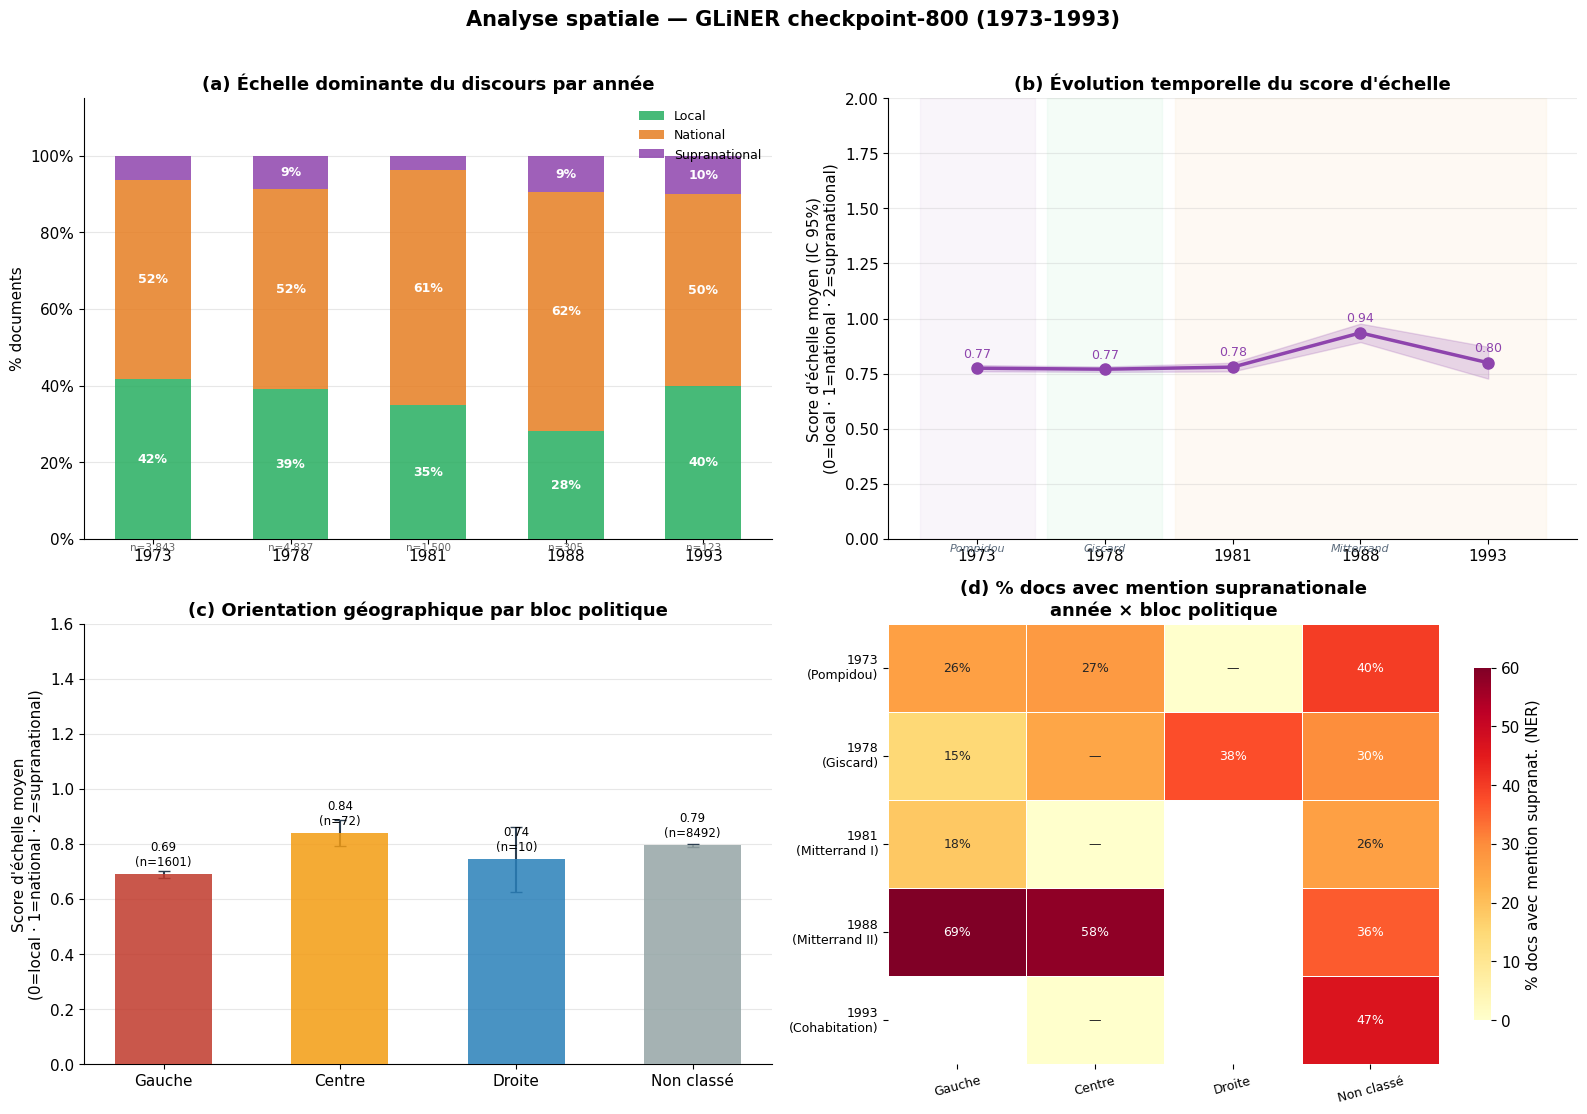

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/fig_spatial1_gliner_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# (a) Barres empilées
ax = axes[0,0]
scale_yr = df_yr.groupby(["annee","dominant_scale"]).size().unstack(fill_value=0)
for col in ["local","national","supranational","inconnu"]:
    if col not in scale_yr.columns: scale_yr[col] = 0
pct = (scale_yr[["local","national","supranational"]]
       .div(scale_yr[["local","national","supranational"]].sum(axis=1), axis=0) * 100)
pct = pct.reindex(ANNEE_ORDER, fill_value=0)
x = np.arange(len(ANNEE_ORDER)); bot = np.zeros(len(ANNEE_ORDER))
for scale in ["local","national","supranational"]:
    vals = pct[scale].values
    bars = ax.bar(x, vals, width=.55, bottom=bot, label=scale.capitalize(),
                  color=C_SCALE[scale], alpha=.85, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 8:
            ax.text(bar.get_x()+bar.get_width()/2, bot[i]+v/2, f"{v:.0f}%",
                    ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bot += vals
for i, yr in enumerate(ANNEE_ORDER):
    ax.text(i, -1, f"n={n_docs_yr.get(yr,0):,}", ha="center", va="top", fontsize=7.5, color="#666")
ax.set_xticks(x); ax.set_xticklabels([str(y) for y in ANNEE_ORDER])
ax.set_ylabel("% documents"); ax.set_ylim(0, 115)
ax.set_title("(a) Échelle dominante du discours par année")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper right", fontsize=9); ax.grid(axis="y", alpha=.3, zorder=0)

# (b) Score d'échelle moyen avec IC
ax2 = axes[0,1]
means = [df_yr[df_yr["annee"]==yr]["scale_score"].mean() for yr in ANNEE_ORDER]
cis   = [df_yr[df_yr["annee"]==yr]["scale_score"].sem()*1.96 for yr in ANNEE_ORDER]
ax2.plot(range(len(ANNEE_ORDER)), means, "o-", color="#8e44ad",
         linewidth=2.5, markersize=8, zorder=3)
ax2.fill_between(range(len(ANNEE_ORDER)),
                 [m-e for m,e in zip(means,cis)],
                 [m+e for m,e in zip(means,cis)], alpha=.2, color="#8e44ad")
for i, (m, e) in enumerate(zip(means, cis)):
    ax2.annotate(f"{m:.2f}", (i,m), xytext=(0,8),
                 textcoords="offset points", ha="center", fontsize=9, color="#8e44ad")
add_pres_bands(ax2, y_off=-.02)
yr_ticks(ax2)
ax2.set_ylabel("Score d'échelle moyen (IC 95%)\n(0=local · 1=national · 2=supranational)")
ax2.set_title("(b) Évolution temporelle du score d'échelle")
ax2.set_ylim(0, 2); ax2.grid(axis="y", alpha=.25)

# (c) Score par bloc
ax3 = axes[1,0]
bs = df_yr.groupby("bloc_politique")["scale_score"].agg(["mean","count","std"]).reindex(BLOC_ORDER)
se = bs["std"] / np.sqrt(bs["count"])
x3 = np.arange(len(BLOC_ORDER))
bars = ax3.bar(x3, bs["mean"].fillna(0), width=.55,
               color=[C_BLOC[b] for b in BLOC_ORDER], alpha=.85, zorder=3)
ax3.errorbar(x3, bs["mean"].fillna(0), yerr=se.fillna(0),
             fmt="none", color="#2c3e50", capsize=4, linewidth=1.5)
for i, (rect, (_, row)) in enumerate(zip(bars, bs.iterrows())):
    if not np.isnan(row["mean"]):
        ax3.text(rect.get_x()+rect.get_width()/2, row["mean"]+.02,
                 f"{row['mean']:.2f}\n(n={row['count']:.0f})",
                 ha="center", va="bottom", fontsize=8.5)
ax3.set_xticks(x3); ax3.set_xticklabels(["Gauche","Centre","Droite","Non classé"])
ax3.set_ylabel("Score d'échelle moyen\n(0=local · 1=national · 2=supranational)")
ax3.set_title("(c) Orientation géographique par bloc politique")
ax3.set_ylim(0, 1.6); ax3.grid(axis="y", alpha=.3, zorder=0)

# (d) Heatmap
ax4 = axes[1,1]
hm = pd.DataFrame(
    [{b: df_yr[(df_yr["annee"]==yr)&(df_yr["bloc_politique"]==b)]["has_intl"].mean()*100
      for b in BLOC_ORDER} for yr in ANNEE_ORDER],
    index=ANNEE_ORDER, columns=BLOC_ORDER)
hm_n = pd.DataFrame(
    [{b: len(df_yr[(df_yr["annee"]==yr)&(df_yr["bloc_politique"]==b)])
      for b in BLOC_ORDER} for yr in ANNEE_ORDER],
    index=ANNEE_ORDER, columns=BLOC_ORDER)
annot = hm.fillna(0).round(0).astype(int).astype(str) + "%"
annot = annot.where(hm_n >= 5, other="—")
sns.heatmap(hm, annot=annot, fmt="", cmap="YlOrRd", vmin=0, vmax=60, ax=ax4,
            linewidths=.5, linecolor="white",
            cbar_kws={"label":"% docs avec mention supranat. (NER)","shrink":.8},
            annot_kws={"size":9})
ax4.set_yticklabels([f"{y}\n({PRES_LABELS[y]})" for y in ANNEE_ORDER], rotation=0, fontsize=9)
ax4.set_xticklabels(["Gauche","Centre","Droite","Non classé"], rotation=15, fontsize=9)
ax4.set_title("(d) % docs avec mention supranationale\nannée × bloc politique")

fig.suptitle("Analyse spatiale — GLiNER checkpoint-800 (1973-1993)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial1_gliner_overview.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial1_gliner_overview.png")


## 6 — Figure 2 : Top lieux par portée géographique

In [ ]:
# Classifier toutes les mentions LOC du corpus
all_locs = []
for doc in docs_gliner:
    if doc["annee"] not in ANNEE_ORDER: continue
    meta = meta_dict.get(doc["id"], {})
    dept = meta.get("departement-nom", doc.get("departement",""))
    for e in doc.get("loc", []):
        cat = classify_loc(e["texte"], dept)
        all_locs.append({"texte": e["texte"], "norm_txt": norm(e["texte"]),
                         "cat": cat, "annee": doc["annee"]})

df_locs = pd.DataFrame(all_locs)
print(f"Total mentions LOC : {len(df_locs):,}")
print("Par catégorie:")
print(df_locs["cat"].value_counts().to_string())


Total mentions LOC : 120,683
Par catégorie:
cat
unknown          74471
national         27845
local            12474
supranational     5893


In [ ]:
# ── Taux de classification : quantification et visualisation ─────────────────
total_mentions = len(df_locs)
known = df_locs[df_locs["cat"] != "unknown"]
n_known = len(known)
n_unknown = total_mentions - n_known

print(f"Total mentions LOC détectées  : {total_mentions:,}")
print(f"Classifiées                   : {n_known:,}  ({n_known/total_mentions*100:.1f}%)")
print(f"Non classifiées (unknown)     : {n_unknown:,}  ({n_unknown/total_mentions*100:.1f}%)")
print()
print("Répartition des mentions CLASSIFIÉES :")
for cat in ["local","national","supranational"]:
    n = len(df_locs[df_locs["cat"]==cat])
    print(f"  {cat:<15} : {n:,}  ({n/n_known*100:.1f}% des classifiées | {n/total_mentions*100:.1f}% du total)")

print()
print("⚠  Note méthodologique : le score d'échelle est calculé sur les")
print(f"   {n_known:,} mentions classifiées seulement ({n_known/total_mentions*100:.1f}% du total LOC).")
print("   Les mentions 'unknown' correspondent principalement à des communes")
print("   françaises de taille moyenne non couvertes par le gazetteer.")
print("   Ce biais tend à sous-estimer légèrement l'échelle nationale.")

# ── Figure : répartition global vs classifié ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Camembert global
ax = axes[0]
sizes_global = [n_known, n_unknown]
colors_global = ["#2ecc71", "#bdc3c7"]
ax.pie(sizes_global, labels=[f"Classifiées\n{n_known/total_mentions*100:.1f}%",
                               f"Unknown\n{n_unknown/total_mentions*100:.1f}%"],
       colors=colors_global, autopct=None, startangle=90,
       wedgeprops={"edgecolor":"white","linewidth":1.5})
ax.set_title(f"(a) Taux de classification\n(total : {total_mentions:,} mentions LOC)")

# (b) Barres : répartition des mentions classifiées par catégorie
ax2 = axes[1]
cats = ["local", "national", "supranational"]
vals = [len(df_locs[df_locs["cat"]==c]) for c in cats]
colors_cats = [C_SCALE[c] for c in cats]
bars = ax2.bar(cats, vals, color=colors_cats, alpha=0.85, width=0.5)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x()+bar.get_width()/2, v+30,
             f"{v:,}\n({v/n_known*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("Nombre de mentions")
ax2.set_title(f"(b) Répartition des {n_known:,} mentions classifiées")
ax2.set_xticklabels(["Local", "National", "Supranational"])
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Couverture du gazetteer (GLiNER → classification spatiale)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial0_coverage.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial0_coverage.png")


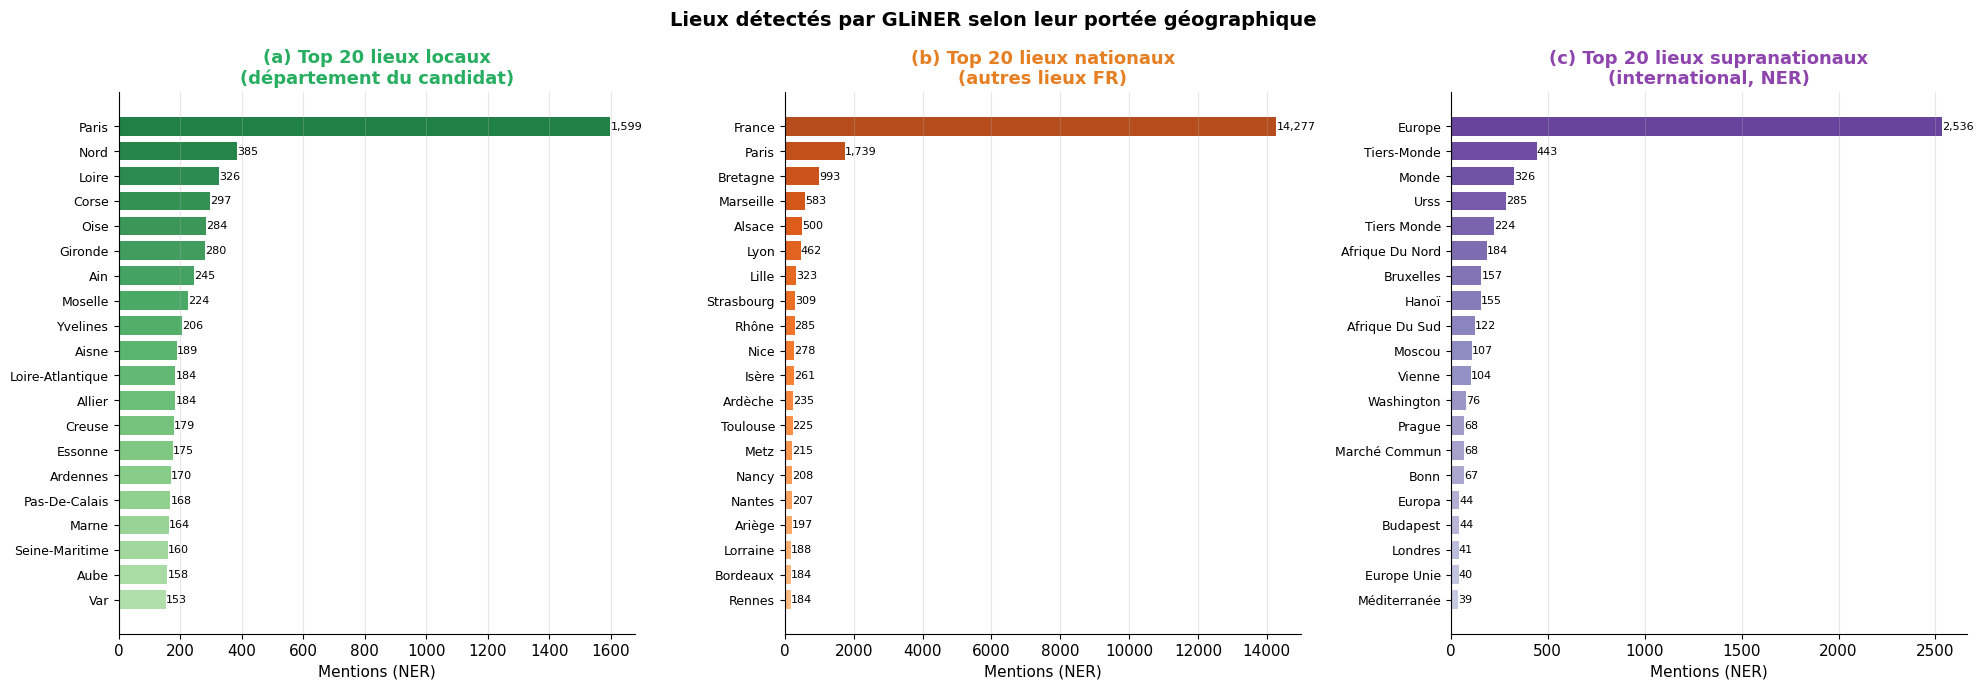

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/fig_spatial2_gliner_lieux.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, cat, cmap_name, title in [
    (axes[0], "local",        "Greens",  "(a) Top 20 lieux locaux\n(département du candidat)"),
    (axes[1], "national",     "Oranges", "(b) Top 20 lieux nationaux\n(autres lieux FR)"),
    (axes[2], "supranational","Purples", "(c) Top 20 lieux supranationaux\n(international, NER)"),
]:
    sub = df_locs[df_locs["cat"] == cat]
    top = sub["norm_txt"].value_counts().head(20)
    cap_map = sub.groupby("norm_txt")["texte"].agg(lambda x: x.value_counts().index[0])
    labels  = [cap_map.get(k, k).title() for k in top.index][::-1]
    vals    = top.values[::-1]; y_pos = range(len(vals))
    cmap_fn = plt.colormaps[cmap_name]
    colors  = cmap_fn(np.linspace(.35, .85, len(vals)))
    ax.barh(list(y_pos), vals, color=colors, alpha=.9, height=.75)
    for i, v in enumerate(vals):
        ax.text(v+.3, i, f"{v:,}", va="center", fontsize=8)
    ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Mentions (NER)")
    color_map = {"local":"#27ae60","national":"#e67e22","supranational":"#8e44ad"}
    ax.set_title(title, color=color_map[cat])
    ax.grid(axis="x", alpha=.3)

fig.suptitle("Lieux détectés par GLiNER selon leur portée géographique",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial2_gliner_lieux.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial2_gliner_lieux.png")


## 7 — Figure 3 : Évolution des références supranationales

In [ ]:
intl_locs = df_locs[df_locs["cat"] == "supranational"].copy()
cap_map_intl = intl_locs.groupby("norm_txt")["texte"].agg(lambda x: x.value_counts().index[0])

print(f"Total mentions supranationales (NER) : {len(intl_locs):,}")
print("Top 15 :")
print(intl_locs["norm_txt"].value_counts().head(15).to_string())


Total mentions supranationales (NER) : 5,893
Top 15 :
norm_txt
europe             2536
tiers-monde         443
monde               326
urss                285
tiers monde         224
afrique du nord     184
bruxelles           157
hanoi               155
afrique du sud      122
moscou              107
vienne              104
washington           76
prague               68
marche commun        68
bonn                 67


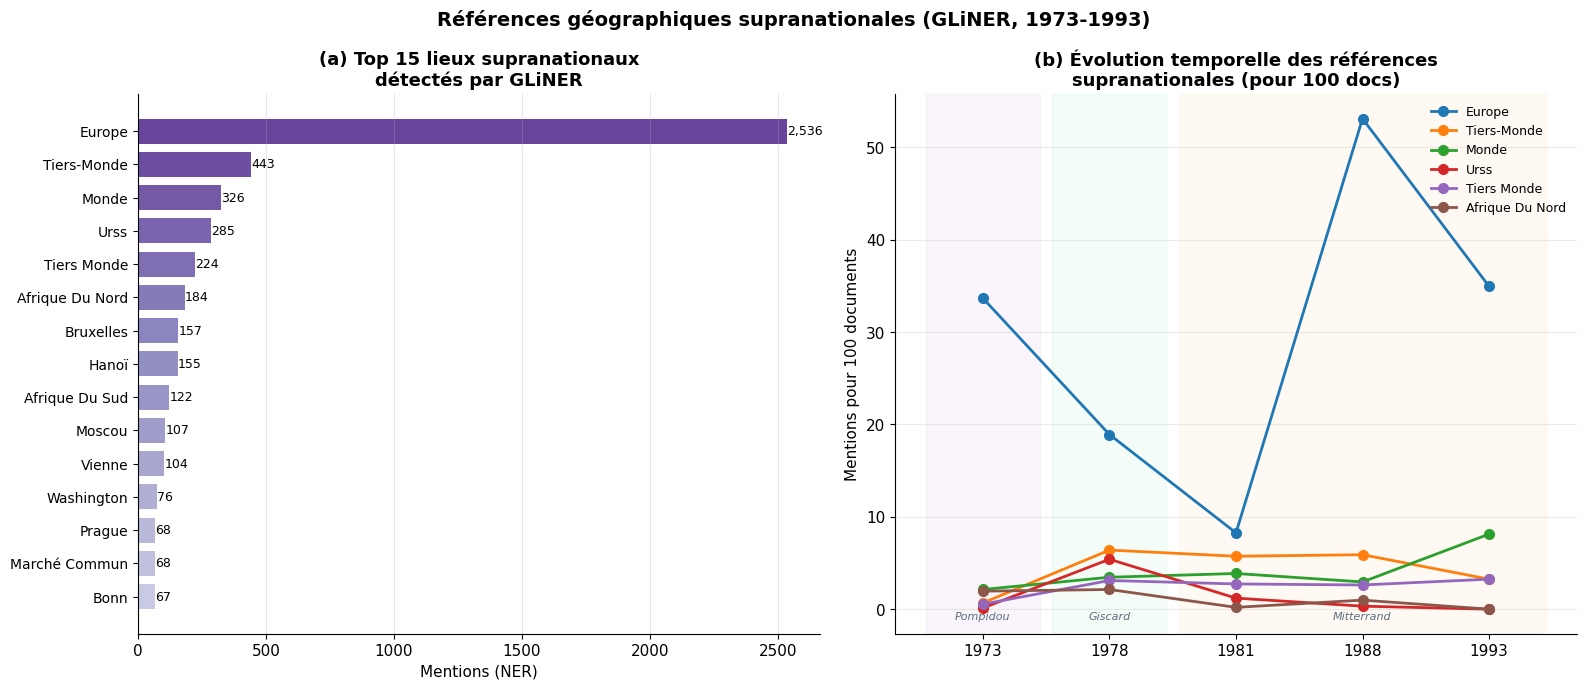

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/fig_spatial3_gliner_intl.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) Barres horizontales top 15
ax = axes[0]
top_intl = intl_locs["norm_txt"].value_counts().head(15)
labels_intl = [cap_map_intl.get(k, k).title() for k in top_intl.index][::-1]
vals_intl   = top_intl.values[::-1]; y_pos = range(len(vals_intl))
cmap_p = plt.colormaps["Purples"](np.linspace(.35, .85, len(vals_intl)))
ax.barh(list(y_pos), vals_intl, color=cmap_p, alpha=.9, height=.75)
for i, v in enumerate(vals_intl):
    ax.text(v+.5, i, f"{v:,}", va="center", fontsize=9)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels_intl, fontsize=10)
ax.set_xlabel("Mentions (NER)")
ax.set_title("(a) Top 15 lieux supranationaux\ndétectés par GLiNER")
ax.grid(axis="x", alpha=.3)

# (b) Évolution des top 6 par année
ax2 = axes[1]
top6 = intl_locs["norm_txt"].value_counts().head(6).index.tolist()
for loc_n in top6:
    vals_yr = [
        len(intl_locs[(intl_locs["norm_txt"]==loc_n) & (intl_locs["annee"]==yr)])
        / n_docs_yr.get(yr, 1) * 100
        for yr in ANNEE_ORDER
    ]
    if max(vals_yr) > 0:
        lbl = cap_map_intl.get(loc_n, loc_n).title()
        ax2.plot(range(len(ANNEE_ORDER)), vals_yr, "o-",
                 linewidth=2, markersize=7, label=lbl, zorder=3)
add_pres_bands(ax2, y_off=-.3)
yr_ticks(ax2)
ax2.set_ylabel("Mentions pour 100 documents")
ax2.set_title("(b) Évolution temporelle des références\nsupranationales (pour 100 docs)")
ax2.legend(fontsize=9, loc="upper right"); ax2.grid(axis="y", alpha=.25)

fig.suptitle("Références géographiques supranationales (GLiNER, 1973-1993)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial3_gliner_intl.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial3_gliner_intl.png")


## 8 — Figure 4 : Échelle spatiale × Sentiment envers le président

> Croisement avec `leaders_sentiment_corpus.xlsx`.


Docs matchés : 2,111/6,346 (33.3%)


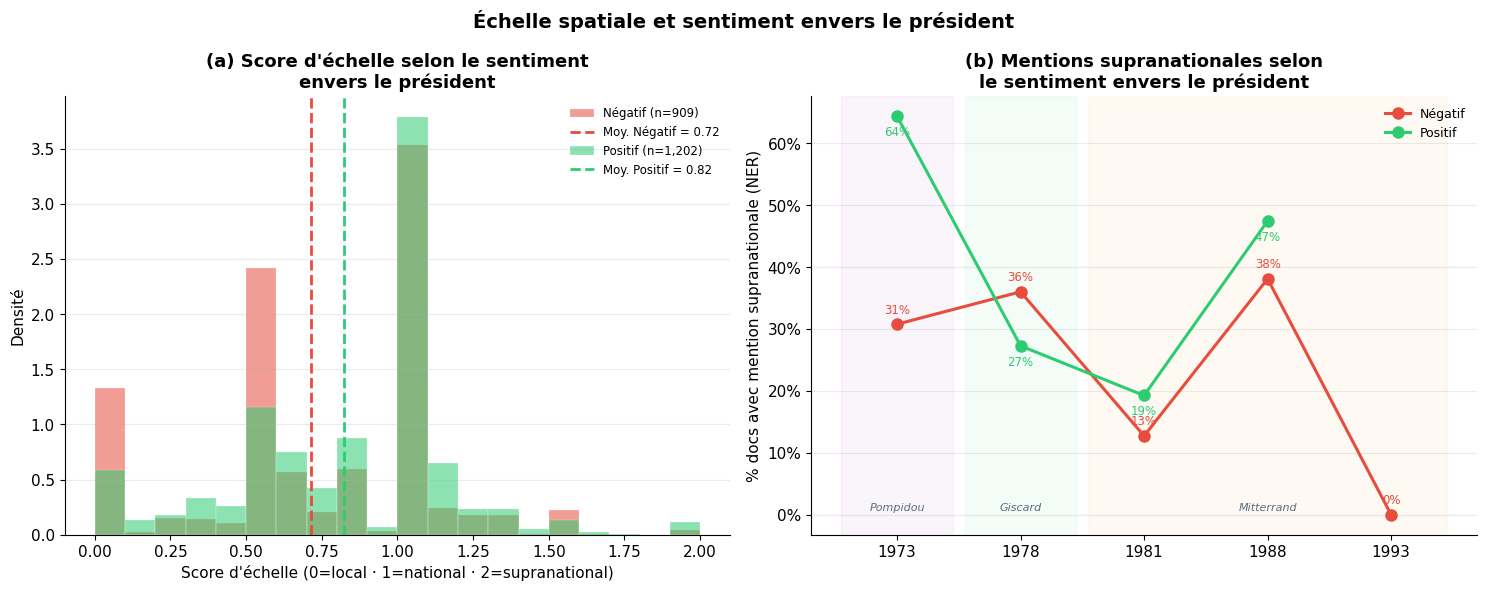

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/fig_spatial4_sentiment.png


In [ ]:
df_merge = df_sentiment.merge(
    df[["id","scale_score","has_intl","n_loc_local","n_loc_national","n_intl"]],
    left_on="file_id", right_on="id", how="left"
)
matched = df_merge["scale_score"].notna().sum()
print(f"Docs matchés : {matched:,}/{len(df_merge):,} ({matched/len(df_merge)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for sent, color, label in [("négatif","#e74c3c","Négatif"),("positif","#2ecc71","Positif")]:
    sub = df_merge[df_merge["sentiment_president"]==sent]["scale_score"].dropna()
    if len(sub) == 0: continue
    ax.hist(sub, bins=20, alpha=.55, color=color, label=f"{label} (n={len(sub):,})",
            density=True, edgecolor="white", linewidth=.3)
    ax.axvline(sub.mean(), color=color, linestyle="--", linewidth=2,
               label=f"Moy. {label} = {sub.mean():.2f}")
ax.set_xlabel("Score d'échelle (0=local · 1=national · 2=supranational)")
ax.set_ylabel("Densité")
ax.set_title("(a) Score d'échelle selon le sentiment\nenvers le président")
ax.legend(fontsize=8.5); ax.grid(axis="y", alpha=.25)

ax2 = axes[1]
for sent, color, label in [("négatif","#e74c3c","Négatif"),("positif","#2ecc71","Positif")]:
    sub = df_merge[df_merge["sentiment_president"]==sent]
    vals = [sub[sub["annee"]==yr]["has_intl"].mean()*100 for yr in ANNEE_ORDER]
    ax2.plot(range(len(ANNEE_ORDER)), vals, "o-", color=color,
             linewidth=2.2, markersize=8, label=label, zorder=3)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            offset = 8 if sent=="négatif" else -14
            ax2.annotate(f"{v:.0f}%", (i,v), xytext=(0,offset),
                         textcoords="offset points", ha="center", fontsize=8.5, color=color)
add_pres_bands(ax2, y_off=2)
yr_ticks(ax2)
ax2.set_ylabel("% docs avec mention supranationale (NER)")
ax2.set_title("(b) Mentions supranationales selon\nle sentiment envers le président")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=.25)

fig.suptitle("Échelle spatiale et sentiment envers le président",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial4_sentiment.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial4_sentiment.png")


## 9 — Figure 5 : Variation par département d'origine

Départements avec ≥10 docs : 100


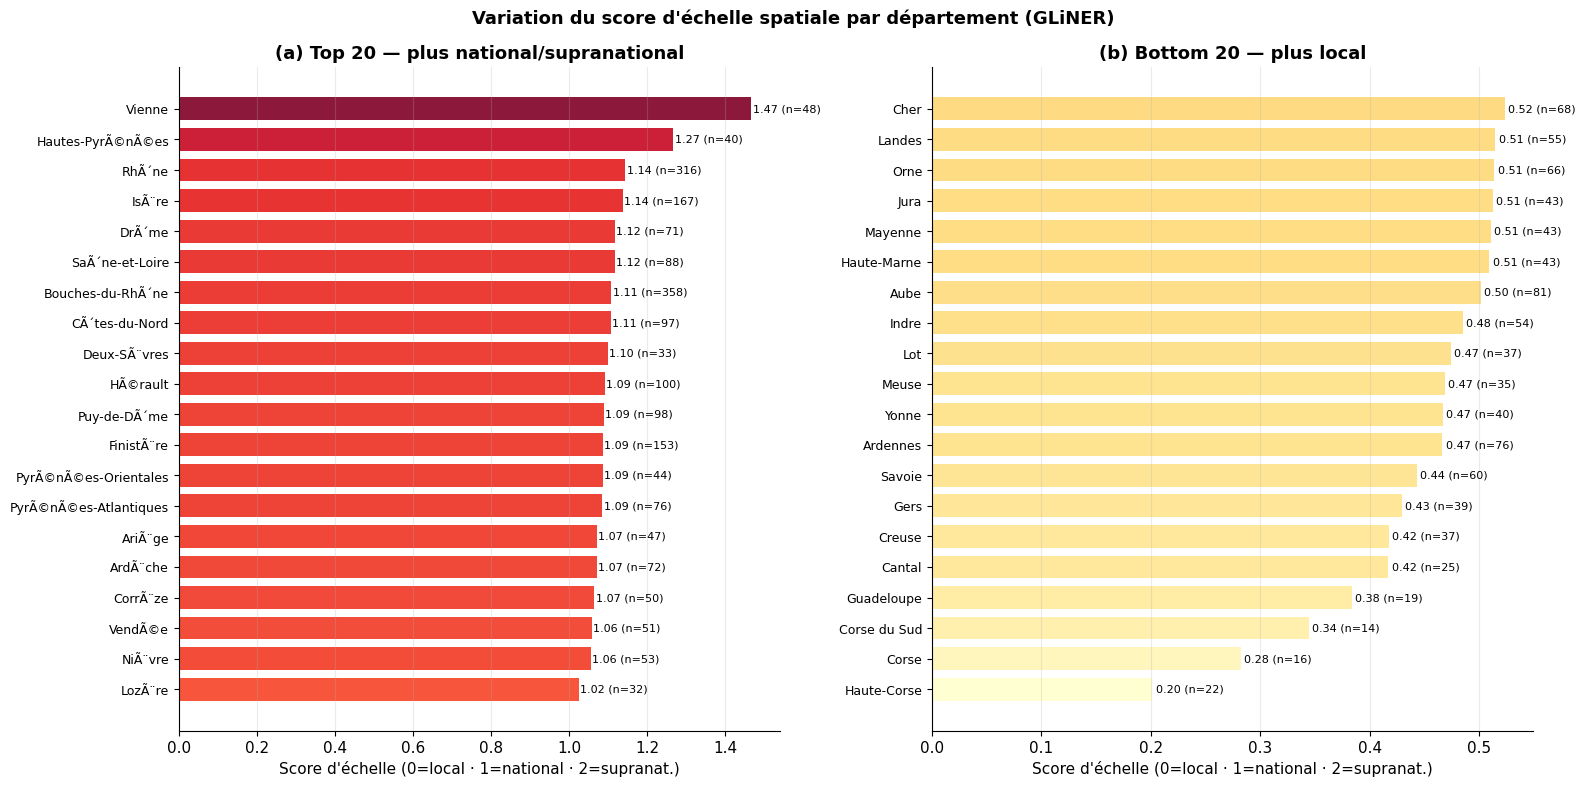

Sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/fig_spatial5_gliner_dept.png


In [ ]:
dept_sc = (df_yr.groupby("departement")["scale_score"]
           .agg(["mean","count","std"])
           .rename(columns={"mean":"score","count":"n","std":"sd"}))
dept_sc = dept_sc[dept_sc["n"] >= 10].sort_values("score", ascending=False)
print(f"Départements avec ≥10 docs : {len(dept_sc)}")

cmap3 = plt.colormaps["YlOrRd"]
norm3 = plt.Normalize(vmin=dept_sc["score"].min(), vmax=dept_sc["score"].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, data, title in [
    (axes[0], dept_sc.head(20), "(a) Top 20 — plus national/supranational"),
    (axes[1], dept_sc.tail(20).sort_values("score"), "(b) Bottom 20 — plus local"),
]:
    d = data.sort_values("score")
    vals = d["score"].values; names = [str(n) for n in d.index]
    y_pos = range(len(vals))
    bars = ax.barh(list(y_pos), vals,
                   color=[cmap3(norm3(v)) for v in vals], alpha=.9, height=.75)
    for bar, v, n in zip(bars, vals, d["n"].values):
        ax.text(v+.003, bar.get_y()+bar.get_height()/2,
                f"{v:.2f} (n={int(n)})", va="center", fontsize=8)
    ax.set_yticks(list(y_pos)); ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Score d'échelle (0=local · 1=national · 2=supranat.)")
    ax.set_title(title); ax.grid(axis="x", alpha=.25)

fig.suptitle("Variation du score d'échelle spatiale par département (GLiNER)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(GRAPHS_DIR / "fig_spatial5_gliner_dept.png")
plt.show()
print("Sauvegardé :", GRAPHS_DIR / "fig_spatial5_gliner_dept.png")


## 10 — Sauvegarde & Synthèse

In [ ]:
OUTPUT_CSV = DATA_DIR / "results/output_best_model/spatial_gliner800_results.csv"
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"CSV sauvegardé : {OUTPUT_CSV} ({df.shape[0]:,} lignes)")


CSV sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/spatial_gliner800_results.csv (10,598 lignes)


In [ ]:
print("=" * 60)
print("SYNTHÈSE — ANALYSE SPATIALE GLiNER checkpoint-800")
print("=" * 60)
print(f"\nDocs analysés          : {len(df):,}")
print(f"Avec mention intl (NER): {df['has_intl'].sum():,} ({df['has_intl'].mean()*100:.1f}%)")
print(f"Score échelle global   : {df['scale_score'].mean():.3f}")

print("\n--- Échelle dominante ---")
print(df["dominant_scale"].value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%").to_string())

print("\n--- Score par bloc politique ---")
print(df.groupby("bloc_politique")["scale_score"].agg(["mean","count"])
      .rename(columns={"mean":"score_moy","count":"n"}).round(3).to_string())

print("\n--- % mentions intl par année ---")
print(df.groupby("annee")["has_intl"].mean().map(lambda x: f"{x*100:.1f}%").to_string())

print("\n--- Top 10 lieux supranationaux ---")
top10 = intl_locs["norm_txt"].value_counts().head(10)
cap10 = intl_locs.groupby("norm_txt")["texte"].agg(lambda x: x.value_counts().index[0])
for k, v in top10.items():
    print(f"  {cap10.get(k,k).title():<30} {v:,}")
print()
print("⚠  Bloc droite : n=10 — effectif trop faible, résultat non interprétable.")


SYNTHÈSE — ANALYSE SPATIALE GLiNER checkpoint-800

Docs analysés          : 10,598
Avec mention intl (NER): 3,354 (31.6%)
Score échelle global   : 0.778

--- Échelle dominante ---
dominant_scale
national         51.5%
local            37.6%
supranational     6.9%
inconnu           4.0%

--- Score par bloc politique ---
                score_moy     n
bloc_politique                 
centre              0.839    72
droite              0.744    10
gauche              0.689  1601
non classé          0.795  8492

--- % mentions intl par année ---
annee
1973    37.2%
1978    28.0%
1981    24.8%
1988    47.2%
1993    46.3%

--- Top 10 lieux supranationaux ---
  Europe                         2,536
  Tiers-Monde                    443
  Monde                          326
  Urss                           285
  Tiers Monde                    224
  Afrique Du Nord                184
  Bruxelles                      157
  Hanoï                          155
  Afrique Du Sud                 122
  Mo

## 11 — Interprétation

### Résultats GLiNER vs ancienne annotation

| Métrique | Ancien JSON | GLiNER checkpoint-800 |
|----------|------------|----------------------|
| Échelle dominante | Local (54%) | **National (51%)** |
| % mentions intl | ~30-55% (regex) | **33-48% (NER direct)** |
| Lieux détectés | Noms de depts seulement | Villes, communes, capitales étrangères |
| Couverture intl | Europe/Monde (regex) | Europe, Tiers-Monde, URSS, Bruxelles, Hanoi... |

### Conclusions principales

| Observation | Résultat | Interprétation |
|-------------|----------|---------------|
| Échelle dominante | Nationale (51%) | Le NER capte les références à d'autres villes FR |
| Bloc le plus international | Centre (0.84) | Héritage européiste UDF/MRP |
| Bloc le plus local | Gauche (0.70) | Ancrage territorial + critique CEE |
| Top lieu intl | **Europe** (2 536 mentions) | Construction européenne au cœur du discours |
| Surprise | **Tiers-Monde** (443) | Décolonisation encore présente en 1973-1978 |
| **Hanoi** détecté | 155 mentions | Guerre du Vietnam dans les PdF de 1973 |
| 1988-1993 | + de mentions intl | Acte Unique (1986) + chute du Mur (1989) |
